<a href="https://colab.research.google.com/github/karlositalo/karlos_mbt_test/blob/main/questao_1_contagem_objetos_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Questão 1 — Contagem de objetos com OpenCV
Solução preparada para execução no Google Colab. A imagem é convertida para cinza, suavizada, binarizada e analisada por contornos.

In [ ]:
# O Google Colab normalmente já possui OpenCV e Matplotlib.
# Este bloco instala apenas se a importação falhar.
try:
    import cv2
except ImportError:
    !pip -q install opencv-python-headless
    import cv2

import numpy as np
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


In [ ]:
# Selecione o arquivo graos.png no seu computador.
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("Nenhuma imagem foi enviada.")

image_path = next(iter(uploaded))
print("Imagem selecionada:", image_path)

Saving graos2.png to graos2.png
Imagem selecionada: graos2.png


Número de objetos encontrados: 66


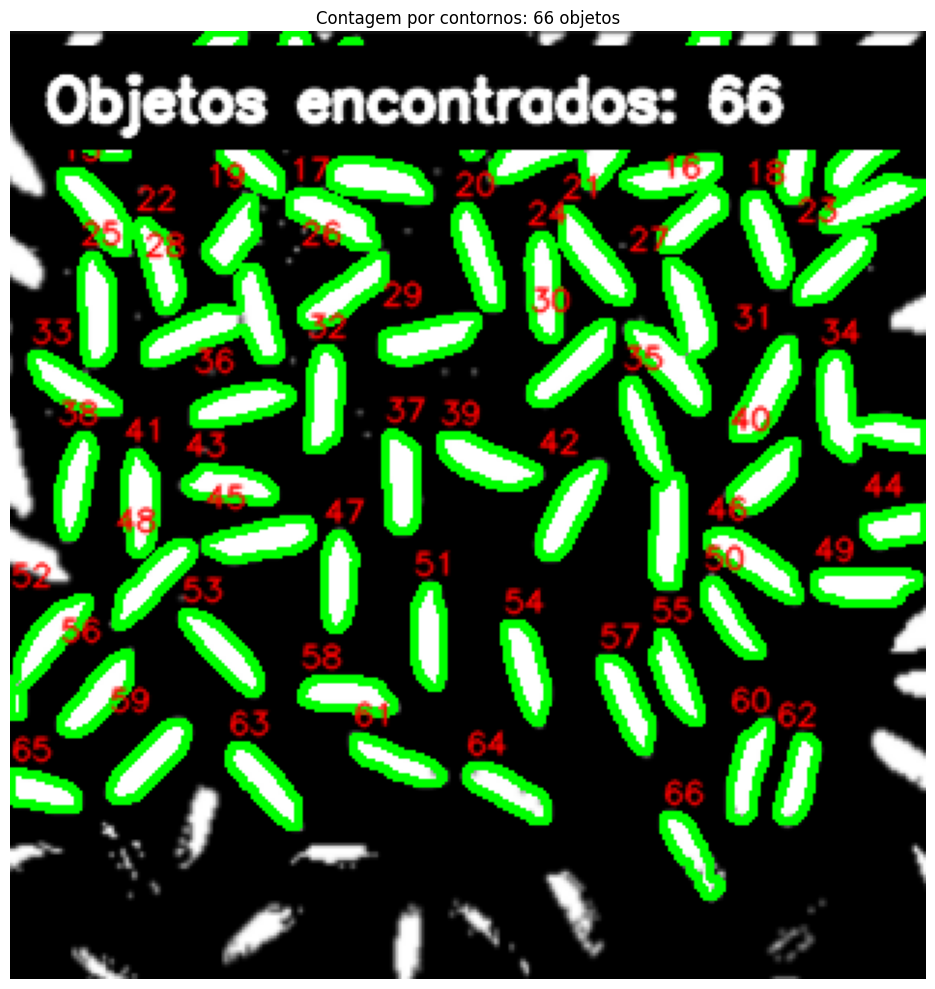

Resultado salvo em: resultado_contagem.png


In [ ]:
# Parâmetro para ignorar pequenos ruídos.
# Ajuste este valor caso a imagem tenha resolução muito diferente.
MIN_AREA = 200

img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(
        f"Não foi possível abrir '{image_path}'. "
        "Verifique se o arquivo é uma imagem válida."
    )

# 1. Conversão para escala de cinza
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Suavização com filtro Gaussiano
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Binarização automática pelo método de Otsu
_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# 4. Pequena abertura morfológica para remover pontos isolados
kernel = np.ones((3, 3), dtype=np.uint8)
binary_clean = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

# 5. Localização dos contornos externos
contours, _ = cv2.findContours(
    binary_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 6. Remoção de contornos muito pequenos
valid_contours = [
    contour for contour in contours
    if cv2.contourArea(contour) >= MIN_AREA
]

# Ordenação apenas para deixar a numeração mais organizada
valid_contours.sort(
    key=lambda contour: (
        cv2.boundingRect(contour)[1],
        cv2.boundingRect(contour)[0]
    )
)

# 7. Desenho dos contornos e dos números
annotated = img.copy()

for index, contour in enumerate(valid_contours, start=1):
    cv2.drawContours(annotated, [contour], -1, (0, 255, 0), 2)

    x, y, w, h = cv2.boundingRect(contour)
    text_y = y - 4 if y > 15 else y + 14

    cv2.putText(
        annotated,
        str(index),
        (x, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.35,
        (0, 0, 255),
        1,
        cv2.LINE_AA
    )

object_count = len(valid_contours)

# Faixa superior com o total encontrado
cv2.rectangle(annotated, (5, 5), (315, 40), (0, 0, 0), -1)
cv2.putText(
    annotated,
    f"Objetos encontrados: {object_count}",
    (12, 30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.65,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

print(f"Número de objetos encontrados: {object_count}")

# No Colab, Matplotlib substitui cv2.imshow/cv2.waitKey.
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Contagem por contornos: {object_count} objetos")
plt.axis("off")
plt.tight_layout()
plt.show()

# Salva a resposta anotada.
output_path = "resultado_contagem.png"
cv2.imwrite(output_path, annotated)
print("Resultado salvo em:", output_path)

In [ ]:
# Opcional: baixar a imagem anotada.
from google.colab import files
files.download("resultado_contagem.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>